# The Bias-Variance Tradeoff: Building Strong Intuitions

This notebook provides a comprehensive, hands-on exploration of one of the most fundamental concepts in machine learning: the bias-variance tradeoff. By the end of this notebook, you'll have strong intuitions about how model complexity affects generalization.

## Learning Objectives

By the end of this notebook, you will:

1. **Understand intuitively** what bias and variance mean in machine learning
2. **Visualize** how model complexity affects both bias and variance
3. **Identify** underfitting (high bias) versus overfitting (high variance)
4. **Recognize** the tradeoff relationship and find the "sweet spot"
5. **Apply** these concepts to real regression and classification problems
6. **Diagnose** model performance issues and select appropriate solutions

## Why Does This Matter?

The bias-variance tradeoff is **central to understanding why machine learning works**. It explains:

- Why simple models sometimes work better than complex ones
- Why more training data helps (and when it doesn't)
- How to choose the right model complexity for your problem
- Why regularization techniques are effective
- The fundamental limits of prediction accuracy

**Real-world analogy**: Think of archery or dart throwing:
- **High bias** = consistently missing the target in the same direction (systematic error)
- **High variance** = shots scattered all over the board (inconsistent, sensitive to small changes)
- **Good model** = tight grouping near the bullseye (low bias, low variance)

Let's build strong intuitions through visualization and hands-on experiments!

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_classification, make_moons
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better visualizations
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['lines.linewidth'] = 2

print("Libraries imported successfully!")

Libraries imported successfully!


---

# Part 1: Understanding Bias (Underfitting)

Let's start by understanding what **bias** means in machine learning.

## Theory: What is Bias?

**Bias** refers to the error introduced by approximating a real-world problem (which may be very complex) with a simplified model. It measures how far off the model's predictions are from the true values **on average**.

**Key characteristics of high bias:**
- The model is **too simple** to capture the underlying patterns
- Leads to **underfitting**: poor performance on both training and test data
- **Systematic error**: consistently wrong in a particular direction
- Example: using a linear model to fit a curved relationship

**Intuition**: A biased model makes strong assumptions about the data structure. When these assumptions are wrong, the model cannot learn the true relationship even with infinite data.

In [2]:
# Generate synthetic data with a nonlinear relationship
# True function: y = sin(x) with some noise
def true_function(x):
    """The underlying true function we're trying to learn"""
    return np.sin(x)

# Generate training data
n_samples = 30
X_train = np.linspace(0, 2*np.pi, n_samples)
noise = np.random.normal(0, 0.15, n_samples)
y_train = true_function(X_train) + noise

# Generate test data (for visualization)
X_test = np.linspace(0, 2*np.pi, 200)
y_test = true_function(X_test)

print(f"Generated {n_samples} training samples")
print(f"Data range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Target range: [{y_train.min():.2f}, {y_train.max():.2f}]")

Generated 30 training samples
Data range: [0.00, 6.28]
Target range: [-1.18, 1.20]


In [3]:
# Fit a linear model (too simple) - HIGH BIAS
X_train_reshaped = X_train.reshape(-1, 1)
X_test_reshaped = X_test.reshape(-1, 1)

# Linear regression (degree 1 polynomial)
linear_model = LinearRegression()
linear_model.fit(X_train_reshaped, y_train)
y_pred_linear = linear_model.predict(X_test_reshaped)

# Calculate training error
y_train_pred = linear_model.predict(X_train_reshaped)
train_error = mean_squared_error(y_train, y_train_pred)

print(f"Linear model training MSE: {train_error:.4f}")
print("\nThis error is high because the linear model cannot capture the sine curve!")

Linear model training MSE: 0.2382

This error is high because the linear model cannot capture the sine curve!


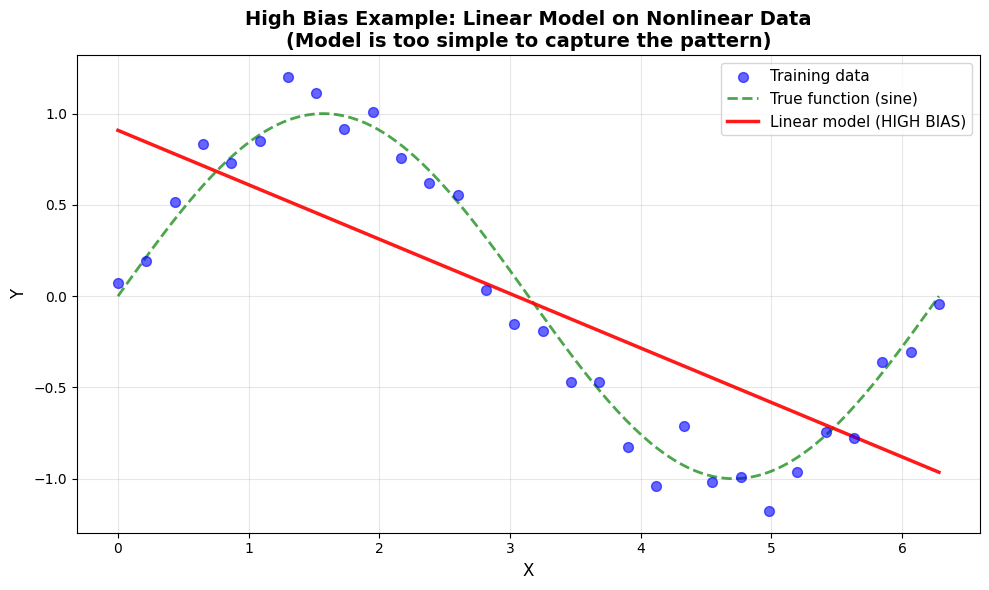


Notice: The linear model systematically misses the curved pattern.
This is BIAS - the model's assumptions are too restrictive!


In [4]:
# Visualize the underfitting (high bias) problem
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot training data
ax.scatter(X_train, y_train, color='blue', s=50, alpha=0.6, label='Training data', zorder=3)

# Plot true function
ax.plot(X_test, y_test, 'g--', linewidth=2, label='True function (sine)', alpha=0.7)

# Plot linear model predictions
ax.plot(X_test, y_pred_linear, 'r-', linewidth=2.5, label='Linear model (HIGH BIAS)', alpha=0.9)

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('High Bias Example: Linear Model on Nonlinear Data\n(Model is too simple to capture the pattern)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNotice: The linear model systematically misses the curved pattern.")
print("This is BIAS - the model's assumptions are too restrictive!")

## Reflection Questions

Before moving on, think about these questions:

1. **Why can't the linear model fit the sine curve?** What assumption is it making?
2. **Would more training data help the linear model?** Why or why not?
3. **What would happen if we used this model on new test data?** Would it perform better or worse than on training data?
4. **Can you think of real-world scenarios where high bias might occur?** (Hint: predicting house prices with only one feature)

*Take a moment to think about these questions before continuing.*

---

# Part 2: Understanding Variance (Overfitting)

Now let's explore the opposite problem: **variance**.

## Theory: What is Variance?

**Variance** refers to the model's sensitivity to small fluctuations in the training data. It measures how much the model's predictions would change if we trained it on different samples from the same distribution.

**Key characteristics of high variance:**
- The model is **too complex** and learns noise in the training data
- Leads to **overfitting**: excellent performance on training data, poor on test data
- **Inconsistent predictions**: predictions change dramatically with different training sets
- Example: using a 15th-degree polynomial to fit 10 data points

**Intuition**: A high-variance model is extremely flexible and can memorize the training data perfectly. However, it fails to generalize because it's learning random noise as if it were a real pattern.

In [5]:
# Fit a high-degree polynomial (too complex) - HIGH VARIANCE
degree = 15

# Transform features to polynomial features
poly_features = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly_features.fit_transform(X_train_reshaped)
X_test_poly = poly_features.transform(X_test_reshaped)

# Fit polynomial model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

# Calculate training error
y_train_pred_poly = poly_model.predict(X_train_poly)
train_error_poly = mean_squared_error(y_train, y_train_pred_poly)

print(f"Polynomial (degree {degree}) training MSE: {train_error_poly:.4f}")
print(f"\nCompare to linear model training MSE: {train_error:.4f}")
print("\nThe polynomial model has MUCH lower training error!")
print("But is it really better? Let's visualize...")

Polynomial (degree 15) training MSE: 0.0108

Compare to linear model training MSE: 0.2382

The polynomial model has MUCH lower training error!
But is it really better? Let's visualize...


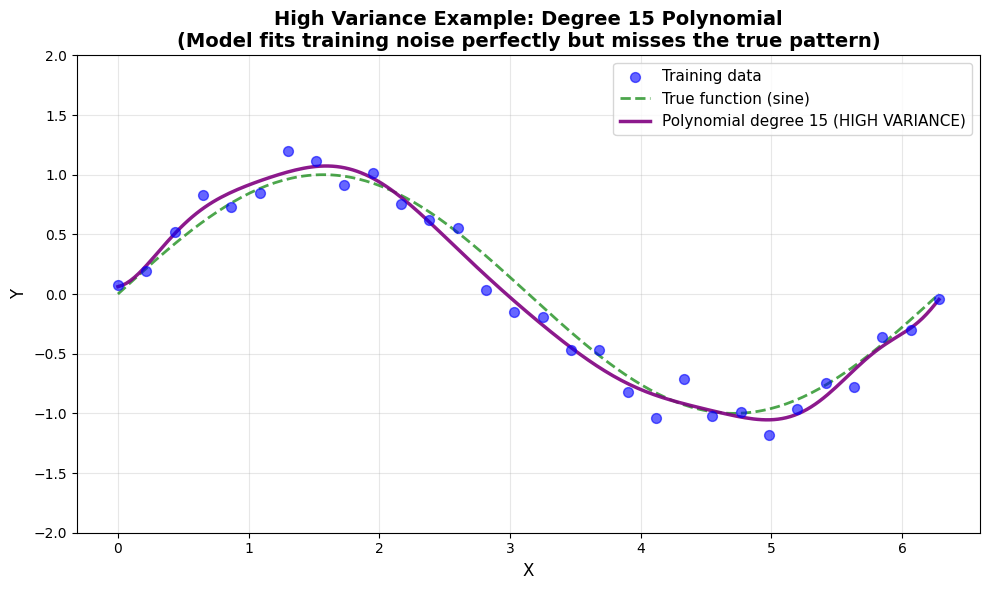


Notice: The polynomial model passes through every training point!
But it wildly oscillates between points, learning the noise.
This is VARIANCE - the model is too sensitive to training data!


In [6]:
# Visualize the overfitting (high variance) problem
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot training data
ax.scatter(X_train, y_train, color='blue', s=50, alpha=0.6, label='Training data', zorder=3)

# Plot true function
ax.plot(X_test, y_test, 'g--', linewidth=2, label='True function (sine)', alpha=0.7)

# Plot polynomial model predictions
ax.plot(X_test, y_pred_poly, 'purple', linewidth=2.5, label=f'Polynomial degree {degree} (HIGH VARIANCE)', alpha=0.9)

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title(f'High Variance Example: Degree {degree} Polynomial\n(Model fits training noise perfectly but misses the true pattern)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([-2, 2])

plt.tight_layout()
plt.show()

print("\nNotice: The polynomial model passes through every training point!")
print("But it wildly oscillates between points, learning the noise.")
print("This is VARIANCE - the model is too sensitive to training data!")

## Demonstrating Variance: Different Training Sets

To truly understand variance, let's train the same complex model on multiple different samples and see how much the predictions change.

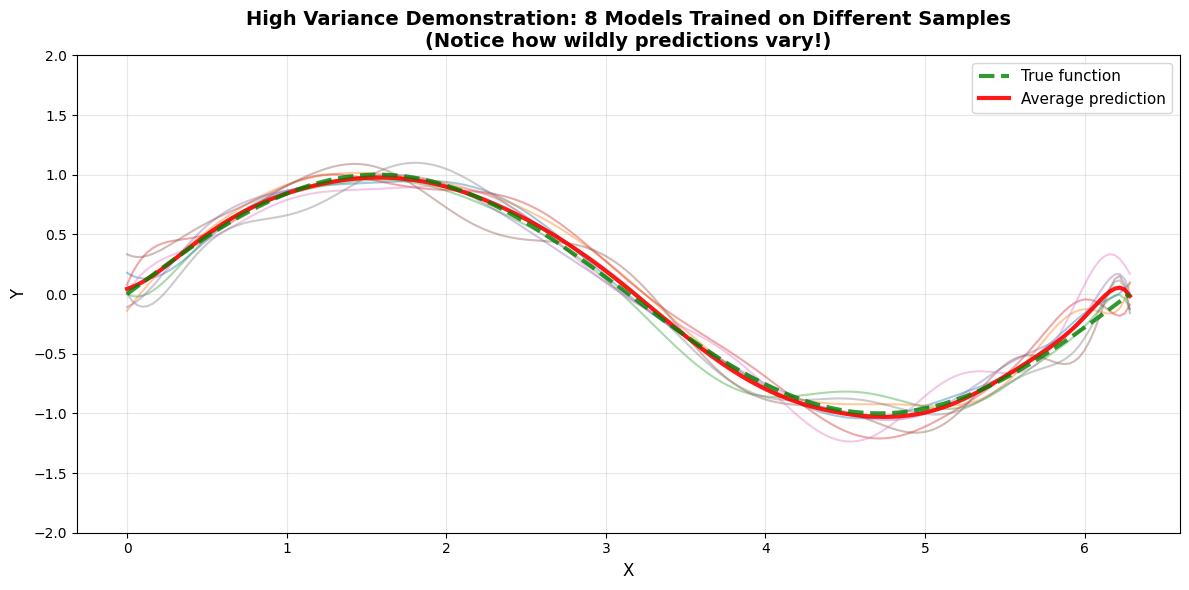


Trained 8 polynomial models (degree 15) on different noisy samples.
Each model produces VERY different predictions!
This instability is what we mean by HIGH VARIANCE.


In [ ]:
# Train multiple high-degree polynomials on different data samples
n_models = 8
degree = 15
predictions_list = []

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Plot true function
ax.plot(X_test, y_test, 'g--', linewidth=3, label='True function', alpha=0.8, zorder=10)

# Train models on different samples
for i in range(n_models):
    # Generate new noisy sample
    noise_i = np.random.normal(0, 0.15, n_samples)
    y_train_i = true_function(X_train) + noise_i
    
    # Fit polynomial model
    X_train_poly_i = poly_features.fit_transform(X_train_reshaped) # TODO: what is this?
    model_i = LinearRegression()
    model_i.fit(X_train_poly_i, y_train_i)
    
    # Predict
    y_pred_i = model_i.predict(X_test_poly)
    predictions_list.append(y_pred_i)
    
    # Plot
    ax.plot(X_test, y_pred_i, alpha=0.4, linewidth=1.5)

# Calculate and plot mean prediction
mean_prediction = np.mean(predictions_list, axis=0)
ax.plot(X_test, mean_prediction, 'r-', linewidth=3, label='Average prediction', alpha=0.9, zorder=9)

ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title(f'High Variance Demonstration: {n_models} Models Trained on Different Samples\n(Notice how wildly predictions vary!)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([-2, 2])

plt.tight_layout()
plt.show()

print(f"\nTrained {n_models} polynomial models (degree {degree}) on different noisy samples.")
print("Each model produces VERY different predictions!")
print("This instability is what we mean by HIGH VARIANCE.")

## Reflection Questions

Before moving on, think about these questions:

1. **Why do the polynomial predictions vary so much between training sets?** What is the model learning?
2. **Would more training data help reduce this variance?** How much would we need?
3. **Notice the average prediction (red line).** How does it compare to the true function?
4. **Can you think of real-world scenarios where high variance might occur?** (Hint: medical diagnosis with thousands of features but few patients)

*Take a moment to think about these questions before continuing.*

## Answers to Reflection Questions

### Question 2: Would more training data help reduce this variance? How much would we need?

**Yes, more training data would significantly help reduce variance!** Here's why:

**Why more data helps:**
1. **More constraints**: With only 30 samples, a degree-15 polynomial has 15 coefficients to estimate. This means there are many degrees of freedom, allowing the model to fit the noise in each training set. With more data points, the model has more constraints and cannot as easily memorize noise.

2. **Better signal-to-noise ratio**: Each additional data point provides information about the true underlying pattern (the sine function). As the training set grows, the signal from the true pattern accumulates, while the random noise averages out across samples.

3. **Stability**: More training data means the model sees more representative samples from the data distribution. Different training sets become more similar to each other, leading to more stable predictions across models.

**How much data would we need?**

For a degree-15 polynomial fitting a sine curve, we'd need **at least 15-20 samples per parameter** for good generalization. Since we have 15 polynomial features (plus bias), we'd ideally want:

- **Minimum**: ~200-300 samples (to constrain the 15 parameters and reduce variance)
- **Recommended**: ~500-1000 samples (for robust, stable predictions)
- **Current**: 30 samples (severely insufficient, leading to high variance)

**Key insight**: The ratio of training samples to model parameters (or model complexity) is crucial. With 30 samples and 15 parameters, we have only 2 samples per parameter - this is a recipe for overfitting!

**Note**: This is a **variance problem**, not a bias problem. If this were a bias problem (model too simple), more data would NOT help. But for variance (model too complex relative to data), more data is the most reliable solution!

---

*You can verify this by experimenting with the "Effect of training set size" section later in this notebook (Part 7). Try increasing `n_train` from 30 to 200 or 500 and observe how the variance decreases!*


---

# Part 3: The Tradeoff Relationship

Now that we understand bias and variance individually, let's explore their **tradeoff relationship**.

## Theory: The Bias-Variance Decomposition

The expected prediction error of a model can be decomposed into three components:

$$\text{Expected Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}$$

Let's understand each term:

1. **Bias**: Error from wrong assumptions in the model
   - Measures how far the average prediction is from the true value
   - $\text{Bias}^2 = (E[\hat{f}(x)] - f(x))^2$

2. **Variance**: Error from sensitivity to training data fluctuations
   - Measures how much predictions vary across different training sets
   - $\text{Variance} = E[(\hat{f}(x) - E[\hat{f}(x)])^2]$

3. **Irreducible Error**: Noise in the data that cannot be reduced
   - Inherent randomness in the problem
   - Sets a lower bound on achievable error

**The Tradeoff**: As model complexity increases:
- Bias decreases (model can fit more complex patterns)
- Variance increases (model becomes more sensitive to noise)

**The sweet spot**: The optimal model complexity minimizes the sum: Bias² + Variance

In [ ]:
# Visualize the conceptual tradeoff curve
# This is a stylized illustration of the principle

model_complexity = np.linspace(0, 10, 100)

# Stylized curves (not from actual data, for illustration)
bias_squared = 5 * np.exp(-model_complexity/2) + 0.1
variance = 0.05 * model_complexity**2
total_error = bias_squared + variance
irreducible_error = np.ones_like(model_complexity) * 0.1

# Find optimal complexity
optimal_idx = np.argmin(total_error)
optimal_complexity = model_complexity[optimal_idx]

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

ax.plot(model_complexity, bias_squared, 'r-', linewidth=3, label='Bias²', alpha=0.8)
ax.plot(model_complexity, variance, 'b-', linewidth=3, label='Variance', alpha=0.8)
ax.plot(model_complexity, total_error, 'purple', linewidth=4, label='Total Error (Bias² + Variance)', alpha=0.9)
ax.plot(model_complexity, irreducible_error, 'g--', linewidth=2, label='Irreducible Error', alpha=0.7)

# Mark optimal point
ax.axvline(optimal_complexity, color='black', linestyle=':', linewidth=2, alpha=0.5)
ax.scatter([optimal_complexity], [total_error[optimal_idx]], color='purple', s=200, 
           marker='*', edgecolors='black', linewidth=2, zorder=10, label='Optimal Complexity')

# Add regions
ax.axvspan(0, 3, alpha=0.1, color='red', label='High Bias Region\n(Underfitting)')
ax.axvspan(7, 10, alpha=0.1, color='blue', label='High Variance Region\n(Overfitting)')

ax.set_xlabel('Model Complexity', fontsize=13, fontweight='bold')
ax.set_ylabel('Error', fontsize=13, fontweight='bold')
ax.set_title('The Bias-Variance Tradeoff\n(Conceptual Illustration)', fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper center')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 10])
ax.set_ylim([0, 6])

# Add annotations
ax.annotate('Bias dominates', xy=(1.5, 3.5), fontsize=11, color='red', fontweight='bold')
ax.annotate('Variance dominates', xy=(7.5, 3.5), fontsize=11, color='blue', fontweight='bold')
ax.annotate('Sweet spot', xy=(optimal_complexity+0.3, total_error[optimal_idx]-0.5), 
            fontsize=11, color='purple', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("1. As complexity increases, Bias² decreases (model can fit more patterns)")
print("2. As complexity increases, Variance increases (model becomes more sensitive)")
print("3. Total Error is U-shaped: too simple OR too complex both hurt performance")
print("4. Optimal complexity balances bias and variance")
print("5. Irreducible error is a lower bound we cannot overcome")

## Why Is There A Tradeoff?

The tradeoff exists because:

**Simple models (low complexity):**
- Make strong assumptions about the data structure
- Cannot fit complex patterns → **HIGH BIAS**
- Stable predictions across training sets → **LOW VARIANCE**
- Example: Linear regression

**Complex models (high complexity):**
- Make few assumptions, very flexible
- Can fit complex patterns → **LOW BIAS**
- Unstable, sensitive to noise → **HIGH VARIANCE**
- Example: High-degree polynomial, deep neural networks

**The challenge**: We need a model that is:
- Complex enough to capture real patterns (low bias)
- Simple enough to ignore noise (low variance)

This is the fundamental challenge of machine learning!

---

# Part 4: Hands-On Example - Polynomial Regression

Now let's empirically measure bias and variance for polynomial models of different degrees.

## Experiment Setup

We'll:
1. Generate multiple training sets from the same distribution
2. Fit polynomial models of varying degrees (1, 2, 3, 5, 7, 9, 12, 15)
3. Measure bias and variance empirically
4. Plot training vs validation error curves
5. Identify the optimal degree

In [ ]:
# Generate multiple datasets for variance estimation
n_datasets = 50  # Number of different training sets
n_train = 30     # Samples per training set
n_test = 200     # Test set size

# Generate fixed test set
X_test_fixed = np.linspace(0, 2*np.pi, n_test).reshape(-1, 1)
y_test_fixed = true_function(X_test_fixed.ravel())

# Generate training sets
X_train_sets = []
y_train_sets = []

for i in range(n_datasets):
    X_train_i = np.linspace(0, 2*np.pi, n_train)
    noise_i = np.random.normal(0, 0.15, n_train)
    y_train_i = true_function(X_train_i) + noise_i
    
    X_train_sets.append(X_train_i.reshape(-1, 1))
    y_train_sets.append(y_train_i)

print(f"Generated {n_datasets} training sets")
print(f"Each training set: {n_train} samples")
print(f"Test set: {n_test} samples")
print("\nReady to train models of varying complexity!")

In [ ]:
# Train polynomial models of different degrees
degrees = [1, 2, 3, 5, 7, 9, 12, 15]

# Store predictions for each degree
predictions_by_degree = {}

for degree in degrees:
    print(f"Training degree {degree} polynomials...")
    predictions_list = []
    
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_test_poly = poly_features.fit_transform(X_test_fixed)
    
    for i in range(n_datasets):
        # Transform training data
        X_train_poly = poly_features.fit_transform(X_train_sets[i])
        
        # Fit model
        model = LinearRegression()
        model.fit(X_train_poly, y_train_sets[i])
        
        # Predict on test set
        y_pred = model.predict(X_test_poly)
        predictions_list.append(y_pred)
    
    predictions_by_degree[degree] = np.array(predictions_list)

print("\nTraining complete!")

In [ ]:
# Calculate bias and variance for each degree
bias_values = []
variance_values = []
total_error_values = []

for degree in degrees:
    predictions = predictions_by_degree[degree]  # Shape: (n_datasets, n_test)
    
    # Calculate mean prediction across all models
    mean_prediction = np.mean(predictions, axis=0)
    
    # Bias: squared difference between mean prediction and true function
    bias_squared = np.mean((mean_prediction - y_test_fixed)**2)
    
    # Variance: expected squared deviation from mean prediction
    variance = np.mean(np.var(predictions, axis=0))
    
    # Total error
    total_error = bias_squared + variance
    
    bias_values.append(bias_squared)
    variance_values.append(variance)
    total_error_values.append(total_error)
    
    print(f"Degree {degree:2d}: Bias² = {bias_squared:.4f}, Variance = {variance:.4f}, Total = {total_error:.4f}")

print("\nBias-variance decomposition complete!")

In [ ]:
# Plot empirical bias-variance tradeoff
optimal_idx = np.argmin(total_error_values)
optimal_degree = degrees[optimal_idx]

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

ax.plot(degrees, bias_values, 'r-o', linewidth=3, markersize=8, label='Bias²', alpha=0.8)
ax.plot(degrees, variance_values, 'b-s', linewidth=3, markersize=8, label='Variance', alpha=0.8)
ax.plot(degrees, total_error_values, 'purple', marker='D', linewidth=4, markersize=10, 
        label='Total Error (Bias² + Variance)', alpha=0.9)

# Mark optimal degree
ax.axvline(optimal_degree, color='black', linestyle=':', linewidth=2, alpha=0.5)
ax.scatter([optimal_degree], [total_error_values[optimal_idx]], color='purple', s=300, 
           marker='*', edgecolors='black', linewidth=2, zorder=10)

ax.set_xlabel('Polynomial Degree (Model Complexity)', fontsize=13, fontweight='bold')
ax.set_ylabel('Error', fontsize=13, fontweight='bold')
ax.set_title('Empirical Bias-Variance Tradeoff\n(Measured from actual polynomial fits)', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees)

# Add annotations
ax.annotate(f'Optimal degree: {optimal_degree}', 
            xy=(optimal_degree, total_error_values[optimal_idx]), 
            xytext=(optimal_degree+2, total_error_values[optimal_idx]+0.01),
            fontsize=11, color='purple', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='purple', lw=2))

plt.tight_layout()
plt.show()

print(f"\nOptimal polynomial degree: {optimal_degree}")
print(f"At this degree: Bias² = {bias_values[optimal_idx]:.4f}, Variance = {variance_values[optimal_idx]:.4f}")

## Visualizing Predictions at Different Complexity Levels

Let's see what the model fits actually look like at different degrees.

In [ ]:
# Visualize fits at different complexity levels
degrees_to_show = [1, 3, 7, 15]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, degree in enumerate(degrees_to_show):
    ax = axes[idx]
    
    # Get predictions for this degree
    predictions = predictions_by_degree[degree]
    mean_prediction = np.mean(predictions, axis=0)
    
    # Plot true function
    ax.plot(X_test_fixed, y_test_fixed, 'g--', linewidth=2.5, label='True function', alpha=0.8)
    
    # Plot individual predictions (sample of them)
    for i in range(min(10, n_datasets)):
        ax.plot(X_test_fixed, predictions[i], alpha=0.2, linewidth=1, color='gray')
    
    # Plot mean prediction
    ax.plot(X_test_fixed, mean_prediction, 'r-', linewidth=3, label='Mean prediction', alpha=0.9)
    
    # Plot one sample training set
    ax.scatter(X_train_sets[0], y_train_sets[0], color='blue', s=30, alpha=0.6, label='Sample training data')
    
    # Title with bias and variance
    degree_idx = degrees.index(degree)
    bias_sq = bias_values[degree_idx]
    var = variance_values[degree_idx]
    
    if degree == 1:
        regime = "HIGH BIAS"
    elif degree == optimal_degree:
        regime = "OPTIMAL"
    elif degree > optimal_degree:
        regime = "HIGH VARIANCE"
    else:
        regime = "Good"
    
    ax.set_title(f'Degree {degree} - {regime}\nBias² = {bias_sq:.4f}, Variance = {var:.4f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-2, 2])

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- Degree 1: Mean prediction is far from truth (HIGH BIAS), but stable (LOW VARIANCE)")
print("- Degree 3-7: Good balance, mean prediction close to truth")
print("- Degree 15: Mean prediction reasonable, but individual predictions wild (HIGH VARIANCE)")

## Training vs Validation Error Curves

A classic way to diagnose bias and variance is to plot training and validation errors as a function of model complexity.

In [ ]:
# Calculate training and validation errors for different degrees
train_errors = []
val_errors = []

# Use one training/validation split
X_single_train = X_train_sets[0]
y_single_train = y_train_sets[0]

for degree in degrees:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    
    # Transform data
    X_train_poly = poly_features.fit_transform(X_single_train)
    X_test_poly = poly_features.transform(X_test_fixed)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_train_poly, y_single_train)
    
    # Calculate errors
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_error = mean_squared_error(y_single_train, y_train_pred)
    val_error = mean_squared_error(y_test_fixed, y_test_pred)
    
    train_errors.append(train_error)
    val_errors.append(val_error)

print("Training and validation errors calculated!")

In [ ]:
# Plot training vs validation error
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

ax.plot(degrees, train_errors, 'b-o', linewidth=3, markersize=8, label='Training Error', alpha=0.8)
ax.plot(degrees, val_errors, 'r-s', linewidth=3, markersize=8, label='Validation Error', alpha=0.8)

# Mark optimal degree
optimal_val_idx = np.argmin(val_errors)
optimal_val_degree = degrees[optimal_val_idx]
ax.axvline(optimal_val_degree, color='black', linestyle=':', linewidth=2, alpha=0.5)
ax.scatter([optimal_val_degree], [val_errors[optimal_val_idx]], color='red', s=300, 
           marker='*', edgecolors='black', linewidth=2, zorder=10)

# Add regions
ax.axvspan(0, 3, alpha=0.1, color='yellow', label='Underfitting region\n(High Bias)')
ax.axvspan(9, 16, alpha=0.1, color='orange', label='Overfitting region\n(High Variance)')

ax.set_xlabel('Polynomial Degree (Model Complexity)', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Squared Error', fontsize=13, fontweight='bold')
ax.set_title('Training vs Validation Error\n(Classic diagnostic for bias-variance tradeoff)', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xticks(degrees)
ax.set_ylim([0, max(max(train_errors), max(val_errors)) * 1.2])

# Add annotations
ax.annotate('Both errors high\n(UNDERFITTING)', xy=(1.5, 0.15), fontsize=10, 
            color='darkred', fontweight='bold', ha='center')
ax.annotate('Training error low,\nValidation error high\n(OVERFITTING)', xy=(12, 0.25), 
            fontsize=10, color='darkred', fontweight='bold', ha='center')
ax.annotate(f'Sweet spot\n(degree {optimal_val_degree})', xy=(optimal_val_degree, val_errors[optimal_val_idx]),
            xytext=(optimal_val_degree-1.5, val_errors[optimal_val_idx]+0.15),
            fontsize=10, color='darkgreen', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))

plt.tight_layout()
plt.show()

print("\nKey Patterns:")
print("1. Training error consistently decreases with complexity (model can fit training data better)")
print("2. Validation error is U-shaped: decreases then increases")
print("3. When curves are far apart: OVERFITTING (high variance)")
print("4. When both curves are high: UNDERFITTING (high bias)")
print(f"5. Optimal degree: {optimal_val_degree} (lowest validation error)")

## Interactive Exploration: Effect of Noise Level

Let's explore how the bias-variance tradeoff changes with different noise levels.

In [ ]:
# EXPERIMENT: Change the noise level and see how it affects the tradeoff
# Higher noise → more variance matters, lower noise → bias matters more

noise_level = 0.15  # Try: 0.05 (low noise), 0.15 (medium), 0.30 (high noise)

print(f"Running experiment with noise_level = {noise_level}")
print("Try changing noise_level above and re-running this cell and the next!\n")

# Generate new datasets with specified noise
X_train_sets_exp = []
y_train_sets_exp = []

for i in range(30):  # Fewer datasets for speed
    X_train_i = np.linspace(0, 2*np.pi, n_train)
    noise_i = np.random.normal(0, noise_level, n_train)
    y_train_i = true_function(X_train_i) + noise_i
    
    X_train_sets_exp.append(X_train_i.reshape(-1, 1))
    y_train_sets_exp.append(y_train_i)

# Calculate optimal degree for this noise level
degrees_exp = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15]
val_errors_exp = []

for degree in degrees_exp:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_test_poly = poly_features.fit_transform(X_test_fixed)
    X_train_poly = poly_features.fit_transform(X_train_sets_exp[0])
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train_sets_exp[0])
    y_pred = model.predict(X_test_poly)
    val_error = mean_squared_error(y_test_fixed, y_pred)
    val_errors_exp.append(val_error)

optimal_degree_exp = degrees_exp[np.argmin(val_errors_exp)]

print(f"Optimal degree with noise = {noise_level}: {optimal_degree_exp}")
print("\nExpected behavior:")
print("- Low noise (0.05): Can use higher degree polynomials (less variance concern)")
print("- High noise (0.30): Must use lower degree (variance becomes dominant problem)")

---

# Part 5: Hands-On Example - k-Nearest Neighbors Classification

The bias-variance tradeoff applies to all ML algorithms. Let's explore it with k-NN classification.

## k-NN and Model Complexity

In k-Nearest Neighbors:
- **Small k** (e.g., k=1): High complexity, flexible decision boundary → LOW BIAS, HIGH VARIANCE
- **Large k** (e.g., k=100): Low complexity, smooth decision boundary → HIGH BIAS, LOW VARIANCE

Note: For k-NN, complexity is **inversely proportional** to k!

In [ ]:
# Generate 2D classification dataset
np.random.seed(42)
X_class, y_class = make_moons(n_samples=200, noise=0.25, random_state=42)

# Split into train and test
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42
)

print(f"Training samples: {len(X_train_class)}")
print(f"Test samples: {len(X_test_class)}")

# Visualize the data
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(X_train_class[:, 0], X_train_class[:, 1], 
                     c=y_train_class, cmap='coolwarm', s=50, alpha=0.6, edgecolors='black')
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Two Moons Classification Dataset', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Class')
plt.tight_layout()
plt.show()

In [ ]:
# Function to visualize decision boundary
def plot_decision_boundary(X, y, model, ax, title):
    """Plot decision boundary for a 2D classification problem"""
    h = 0.02  # Step size in mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title, fontsize=11, fontweight='bold')

print("Decision boundary plotting function defined!")

In [ ]:
# Visualize k-NN with different k values
k_values = [1, 3, 10, 50]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, k in enumerate(k_values):
    # Train k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_class, y_train_class)
    
    # Calculate accuracies
    train_acc = knn.score(X_train_class, y_train_class)
    test_acc = knn.score(X_test_class, y_test_class)
    
    # Determine regime
    if k == 1:
        regime = "HIGH VARIANCE (Overfitting)"
    elif k == 50:
        regime = "HIGH BIAS (Underfitting)"
    else:
        regime = "Good Balance"
    
    # Plot
    title = f'k = {k} - {regime}\nTrain Acc: {train_acc:.3f}, Test Acc: {test_acc:.3f}'
    plot_decision_boundary(X_train_class, y_train_class, knn, axes[idx], title)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- k=1: Very jagged boundary, fits training data perfectly (HIGH VARIANCE)")
print("- k=3-10: Smooth but flexible boundary, good generalization")
print("- k=50: Very smooth boundary, misses important patterns (HIGH BIAS)")

In [ ]:
# Calculate training and test accuracy for range of k values
k_range = range(1, 60, 2)
train_scores_knn = []
test_scores_knn = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_class, y_train_class)
    
    train_scores_knn.append(knn.score(X_train_class, y_train_class))
    test_scores_knn.append(knn.score(X_test_class, y_test_class))

# Find optimal k
optimal_k_idx = np.argmax(test_scores_knn)
optimal_k = list(k_range)[optimal_k_idx]

print(f"Optimal k: {optimal_k}")
print(f"Best test accuracy: {test_scores_knn[optimal_k_idx]:.3f}")

In [ ]:
# Plot accuracy vs k
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

ax.plot(list(k_range), train_scores_knn, 'b-o', linewidth=2, markersize=6, 
        label='Training Accuracy', alpha=0.7)
ax.plot(list(k_range), test_scores_knn, 'r-s', linewidth=2, markersize=6, 
        label='Test Accuracy', alpha=0.7)

# Mark optimal k
ax.axvline(optimal_k, color='black', linestyle=':', linewidth=2, alpha=0.5)
ax.scatter([optimal_k], [test_scores_knn[optimal_k_idx]], color='red', s=300, 
           marker='*', edgecolors='black', linewidth=2, zorder=10)

# Add regions
ax.axvspan(1, 5, alpha=0.1, color='orange', label='High Variance Region')
ax.axvspan(40, 60, alpha=0.1, color='yellow', label='High Bias Region')

ax.set_xlabel('k (Number of Neighbors)', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold')
ax.set_title('k-NN: Training vs Test Accuracy\n(Remember: Lower k = Higher Complexity)', 
             fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Add annotations
ax.annotate('HIGH VARIANCE\n(overfitting)', xy=(1, 0.97), fontsize=10, 
            color='darkred', fontweight='bold')
ax.annotate('HIGH BIAS\n(underfitting)', xy=(45, 0.75), fontsize=10, 
            color='darkred', fontweight='bold')
ax.annotate(f'Optimal k = {optimal_k}', xy=(optimal_k, test_scores_knn[optimal_k_idx]),
            xytext=(optimal_k+8, test_scores_knn[optimal_k_idx]-0.05),
            fontsize=11, color='darkgreen', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))

plt.tight_layout()
plt.show()

print("\nKey Patterns (note: k is inversely related to complexity):")
print("1. Small k: Perfect training accuracy, lower test accuracy (OVERFITTING)")
print("2. Large k: Both accuracies drop (UNDERFITTING)")
print("3. Gap between curves indicates overfitting")
print(f"4. Optimal k = {optimal_k} balances bias and variance")

---

# Part 6: Bias-Variance Decomposition - Deep Dive

Let's perform a detailed Monte Carlo simulation to empirically measure and visualize bias and variance.

## Monte Carlo Approach

To truly understand bias and variance, we need to think about the **sampling distribution** of our model:

1. **Generate many training sets** from the same data distribution
2. **Train a model on each** training set
3. **Measure predictions** at a specific test point across all models
4. **Calculate:**
   - Bias: How far is the average prediction from the truth?
   - Variance: How much do predictions vary across models?

This simulates what would happen if we could collect many different training sets in practice.

In [ ]:
# Detailed bias-variance decomposition at a specific test point
test_point = np.array([[np.pi]])  # Test at x = pi
true_value = true_function(test_point[0, 0])

degrees_decomp = [1, 3, 7, 15]
n_simulations = 100

results_decomp = {}

for degree in degrees_decomp:
    predictions_at_point = []
    
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    test_point_poly = poly_features.fit_transform(test_point)
    
    for sim in range(n_simulations):
        # Generate training data
        X_sim = np.linspace(0, 2*np.pi, 30).reshape(-1, 1)
        y_sim = true_function(X_sim.ravel()) + np.random.normal(0, 0.15, 30)
        
        # Fit model
        X_sim_poly = poly_features.fit_transform(X_sim)
        model = LinearRegression()
        model.fit(X_sim_poly, y_sim)
        
        # Predict at test point
        pred = model.predict(test_point_poly)[0]
        predictions_at_point.append(pred)
    
    predictions_at_point = np.array(predictions_at_point)
    mean_pred = np.mean(predictions_at_point)
    
    # Calculate bias and variance
    bias = mean_pred - true_value
    bias_squared = bias**2
    variance = np.var(predictions_at_point)
    
    results_decomp[degree] = {
        'predictions': predictions_at_point,
        'mean_pred': mean_pred,
        'bias': bias,
        'bias_squared': bias_squared,
        'variance': variance
    }
    
    print(f"Degree {degree:2d}: Bias = {bias:+.4f}, Bias² = {bias_squared:.4f}, Variance = {variance:.4f}")

print(f"\nTrue value at x=π: {true_value:.4f}")

In [ ]:
# Visualize the decomposition
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, degree in enumerate(degrees_decomp):
    ax = axes[idx]
    results = results_decomp[degree]
    predictions = results['predictions']
    mean_pred = results['mean_pred']
    bias = results['bias']
    variance = results['variance']
    
    # Create histogram of predictions
    ax.hist(predictions, bins=20, alpha=0.6, color='blue', edgecolor='black', density=True)
    
    # Mark true value
    ax.axvline(true_value, color='green', linewidth=3, linestyle='--', label='True value', alpha=0.8)
    
    # Mark mean prediction
    ax.axvline(mean_pred, color='red', linewidth=3, linestyle='-', label='Mean prediction', alpha=0.8)
    
    # Add bias arrow
    if abs(bias) > 0.01:
        ax.annotate('', xy=(mean_pred, 0.5), xytext=(true_value, 0.5),
                   arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
        ax.text((mean_pred + true_value)/2, 0.55, f'Bias = {bias:+.3f}',
               ha='center', fontsize=9, color='purple', fontweight='bold')
    
    ax.set_xlabel('Prediction Value', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'Degree {degree}\nBias² = {results["bias_squared"]:.4f}, Variance = {variance:.4f}',
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Describe regime
    if degree == 1:
        regime = "HIGH BIAS\n(mean far from truth)\nLOW VARIANCE\n(tight distribution)"
    elif degree == 15:
        regime = "LOW BIAS\n(mean near truth)\nHIGH VARIANCE\n(wide distribution)"
    else:
        regime = "Good balance"
    
    ax.text(0.98, 0.97, regime, transform=ax.transAxes, fontsize=9,
           verticalalignment='top', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nVisualization Key:")
print("- Green line: True value we're trying to predict")
print("- Red line: Average prediction across all models")
print("- Histogram: Distribution of predictions from different training sets")
print("- Width of histogram: Variance (prediction instability)")
print("- Distance between lines: Bias (systematic error)")

## Visualizing Predictions Across the Input Space

Let's extend this analysis across all test points to see spatial patterns.

In [ ]:
# Analyze bias and variance across the entire input space
degree_to_analyze = 7
n_sims_spatial = 30

# Generate test points
X_test_spatial = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_true_spatial = true_function(X_test_spatial.ravel())

# Collect predictions
all_predictions = []

poly_features = PolynomialFeatures(degree=degree_to_analyze, include_bias=False)
X_test_spatial_poly = poly_features.fit_transform(X_test_spatial)

for sim in range(n_sims_spatial):
    # Generate training data
    X_train_sim = np.linspace(0, 2*np.pi, 30).reshape(-1, 1)
    y_train_sim = true_function(X_train_sim.ravel()) + np.random.normal(0, 0.15, 30)
    
    # Fit model
    X_train_sim_poly = poly_features.fit_transform(X_train_sim)
    model = LinearRegression()
    model.fit(X_train_sim_poly, y_train_sim)
    
    # Predict
    y_pred_sim = model.predict(X_test_spatial_poly)
    all_predictions.append(y_pred_sim)

all_predictions = np.array(all_predictions)  # Shape: (n_sims, n_test_points)
mean_predictions = np.mean(all_predictions, axis=0)
std_predictions = np.std(all_predictions, axis=0)
bias_spatial = mean_predictions - y_true_spatial

print(f"Computed spatial bias and variance for degree {degree_to_analyze} polynomial")

In [ ]:
# Visualize spatial patterns
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

# Panel 1: Individual predictions + mean
ax1 = axes[0]
for i in range(min(15, n_sims_spatial)):
    ax1.plot(X_test_spatial, all_predictions[i], alpha=0.3, linewidth=1, color='gray')
ax1.plot(X_test_spatial, y_true_spatial, 'g--', linewidth=3, label='True function', alpha=0.8)
ax1.plot(X_test_spatial, mean_predictions, 'r-', linewidth=3, label='Mean prediction', alpha=0.9)
ax1.fill_between(X_test_spatial.ravel(), 
                  mean_predictions - std_predictions, 
                  mean_predictions + std_predictions,
                  alpha=0.2, color='blue', label='±1 std (variance)')
ax1.set_ylabel('Y', fontsize=12)
ax1.set_title(f'Degree {degree_to_analyze} Polynomial: Predictions Across Input Space', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Panel 2: Bias across input space
ax2 = axes[1]
ax2.plot(X_test_spatial, bias_spatial, 'purple', linewidth=3)
ax2.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax2.fill_between(X_test_spatial.ravel(), 0, bias_spatial, alpha=0.3, color='purple')
ax2.set_ylabel('Bias', fontsize=12)
ax2.set_title('Bias Across Input Space (Mean Prediction - True Value)', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Panel 3: Variance (std) across input space
ax3 = axes[2]
ax3.plot(X_test_spatial, std_predictions, 'blue', linewidth=3)
ax3.fill_between(X_test_spatial.ravel(), 0, std_predictions, alpha=0.3, color='blue')
ax3.set_xlabel('X', fontsize=12)
ax3.set_ylabel('Standard Deviation\n(sqrt of Variance)', fontsize=12)
ax3.set_title('Prediction Variability Across Input Space', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInsights:")
print("- Top: Individual model predictions vary, but average is close to truth")
print("- Middle: Bias (systematic error) is relatively small and varies spatially")
print("- Bottom: Variance (prediction uncertainty) changes across input space")
print("- Often variance is higher at boundaries or where data is sparse")

---

# Part 7: Practical Implications

Now that we deeply understand bias and variance, let's learn how to **diagnose and fix** these problems in practice.

## Diagnostic Framework

### How to Detect High Bias (Underfitting)

**Symptoms:**
- Training error is HIGH
- Validation/test error is also HIGH
- Both errors are similar (small gap)
- Model performs poorly on both seen and unseen data

**Visual signs:**
- Model predictions are far from true function
- Cannot capture obvious patterns in data
- Both training and validation curves plateau at high error

**Solutions for High Bias:**
1. **Add more features** (more information for model to use)
2. **Use a more complex model** (higher degree polynomial, more layers, etc.)
3. **Reduce regularization** (allow model more freedom)
4. **Train longer** (ensure model has converged)
5. **Try different model architectures** (e.g., neural networks instead of linear)

**Note:** More training data does NOT help high bias! The model is already too simple.

---

### How to Detect High Variance (Overfitting)

**Symptoms:**
- Training error is LOW
- Validation/test error is HIGH
- Large gap between training and validation error
- Model performs well on training data but poorly on new data

**Visual signs:**
- Model fits training points exactly (even noise)
- Wild oscillations or complex patterns that don't generalize
- Predictions vary dramatically with small training set changes

**Solutions for High Variance:**
1. **Get more training data** (most reliable solution)
2. **Use a simpler model** (lower degree, fewer parameters)
3. **Add regularization** (L1, L2, dropout, etc.)
4. **Feature selection** (remove noisy/irrelevant features)
5. **Early stopping** (stop training before overfitting)
6. **Ensemble methods** (bagging, random forests)
7. **Cross-validation** (better estimate of generalization)

**Key insight:** More data helps variance but not bias!

## Decision Tree: What Should I Do?

```
Is training error high?
│
├─ YES: Is validation error also high?
│   │
│   ├─ YES → HIGH BIAS problem (underfitting)
│   │        Solutions: more complex model, more features, less regularization
│   │
│   └─ NO → This is unusual. Check data quality.
│
└─ NO: Is there a large gap to validation error?
    │
    ├─ YES → HIGH VARIANCE problem (overfitting)
    │        Solutions: more data, simpler model, regularization
    │
    └─ NO → Good fit! Model is well-tuned.
```

In [ ]:
# Demonstration: Effect of training set size on bias/variance
# This shows why "more data" helps variance but not bias

sample_sizes = [10, 20, 50, 100, 200]
degrees_to_test = [1, 7, 15]  # Low, medium, high complexity

results_sample_size = {degree: {'train_errors': [], 'val_errors': []} for degree in degrees_to_test}

# Fixed validation set
X_val_fixed = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_val_fixed = true_function(X_val_fixed.ravel())

for n_samples in sample_sizes:
    # Generate training data
    X_train_size = np.linspace(0, 2*np.pi, n_samples).reshape(-1, 1)
    y_train_size = true_function(X_train_size.ravel()) + np.random.normal(0, 0.15, n_samples)
    
    for degree in degrees_to_test:
        poly_features = PolynomialFeatures(degree=degree, include_bias=False)
        
        X_train_poly = poly_features.fit_transform(X_train_size)
        X_val_poly = poly_features.transform(X_val_fixed)
        
        model = LinearRegression()
        model.fit(X_train_poly, y_train_size)
        
        train_error = mean_squared_error(y_train_size, model.predict(X_train_poly))
        val_error = mean_squared_error(y_val_fixed, model.predict(X_val_poly))
        
        results_sample_size[degree]['train_errors'].append(train_error)
        results_sample_size[degree]['val_errors'].append(val_error)

print("Computed learning curves for different model complexities!")

In [ ]:
# Plot learning curves
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

titles = ['Degree 1 (HIGH BIAS)', 'Degree 7 (Good)', 'Degree 15 (HIGH VARIANCE)']

for idx, degree in enumerate(degrees_to_test):
    ax = axes[idx]
    
    train_errors = results_sample_size[degree]['train_errors']
    val_errors = results_sample_size[degree]['val_errors']
    
    ax.plot(sample_sizes, train_errors, 'b-o', linewidth=2, markersize=8, label='Training Error', alpha=0.8)
    ax.plot(sample_sizes, val_errors, 'r-s', linewidth=2, markersize=8, label='Validation Error', alpha=0.8)
    
    ax.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Squared Error', fontsize=12, fontweight='bold')
    ax.set_title(titles[idx], fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 0.3])
    
    # Add interpretation
    if degree == 1:
        interpretation = "Both errors high and flat.\nMore data DOES NOT help!\nNeed more complex model."
    elif degree == 7:
        interpretation = "Validation error decreases.\nMore data helps!\nGood balance achieved."
    else:  # degree == 15
        interpretation = "Large gap between curves.\nMore data helps reduce gap.\nBut simpler model is better."
    
    ax.text(0.5, 0.95, interpretation, transform=ax.transAxes, fontsize=9,
           verticalalignment='top', horizontalalignment='center',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

print("\nKey Lessons:")
print("1. HIGH BIAS (degree 1): More data does NOT help! Both curves stay high.")
print("2. GOOD MODEL (degree 7): Validation error improves with more data.")
print("3. HIGH VARIANCE (degree 15): More data helps, but gap remains. Simpler model is better.")
print("\nRule of thumb: If train & val errors are both high → increase complexity")
print("               If large gap between them → decrease complexity or get more data")

---

# Part 8: Interactive Experimentation

Time to experiment on your own! Modify the parameters below and observe how they affect the bias-variance tradeoff.

## Experiment 1: Varying Noise Levels

Explore how data noise affects optimal model complexity.

In [ ]:
# EXPERIMENT: Vary noise level and find optimal degree

# MODIFY THIS PARAMETER
noise_level_exp = 0.15  # Try: 0.05, 0.15, 0.30, 0.50

print(f"Experiment: Finding optimal polynomial degree with noise = {noise_level_exp}\n")

# Generate data with specified noise
n_train_exp = 40
X_train_exp = np.linspace(0, 2*np.pi, n_train_exp).reshape(-1, 1)
y_train_exp = true_function(X_train_exp.ravel()) + np.random.normal(0, noise_level_exp, n_train_exp)

X_test_exp = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_test_exp = true_function(X_test_exp.ravel())

# Test different degrees
degrees_exp = range(1, 20)
test_errors_exp = []

for degree in degrees_exp:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train_exp)
    X_test_poly = poly_features.transform(X_test_exp)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train_exp)
    
    y_pred = model.predict(X_test_poly)
    test_error = mean_squared_error(y_test_exp, y_pred)
    test_errors_exp.append(test_error)

optimal_degree_exp = list(degrees_exp)[np.argmin(test_errors_exp)]

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(list(degrees_exp), test_errors_exp, 'b-o', linewidth=2, markersize=6)
ax.axvline(optimal_degree_exp, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.scatter([optimal_degree_exp], [test_errors_exp[optimal_degree_exp-1]], 
           color='red', s=200, marker='*', edgecolors='black', linewidth=2, zorder=10)
ax.set_xlabel('Polynomial Degree', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Error', fontsize=12, fontweight='bold')
ax.set_title(f'Optimal Degree with Noise = {noise_level_exp}\nOptimal: {optimal_degree_exp}', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal degree: {optimal_degree_exp}")
print(f"Minimum test error: {min(test_errors_exp):.4f}")
print("\nTry different noise levels and observe:")
print("- Lower noise → can use higher degree (variance is less of a problem)")
print("- Higher noise → must use lower degree (variance dominates)")

## Experiment 2: Varying Training Set Size

See how more data affects the optimal complexity and error rates.

In [ ]:
# EXPERIMENT: Vary training set size

# MODIFY THIS PARAMETER
n_train_size_exp = 50  # Try: 10, 20, 50, 100, 200

print(f"Experiment: Finding optimal polynomial degree with {n_train_size_exp} training samples\n")

# Generate data
X_train_size_exp = np.linspace(0, 2*np.pi, n_train_size_exp).reshape(-1, 1)
y_train_size_exp = true_function(X_train_size_exp.ravel()) + np.random.normal(0, 0.15, n_train_size_exp)

X_test_size_exp = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_test_size_exp = true_function(X_test_size_exp.ravel())

# Test different degrees
degrees_size_exp = range(1, 20)
test_errors_size_exp = []

for degree in degrees_size_exp:
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train_size_exp)
    X_test_poly = poly_features.transform(X_test_size_exp)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train_size_exp)
    
    y_pred = model.predict(X_test_poly)
    test_error = mean_squared_error(y_test_size_exp, y_pred)
    test_errors_size_exp.append(test_error)

optimal_degree_size_exp = list(degrees_size_exp)[np.argmin(test_errors_size_exp)]

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.plot(list(degrees_size_exp), test_errors_size_exp, 'b-o', linewidth=2, markersize=6)
ax.axvline(optimal_degree_size_exp, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.scatter([optimal_degree_size_exp], [test_errors_size_exp[optimal_degree_size_exp-1]], 
           color='red', s=200, marker='*', edgecolors='black', linewidth=2, zorder=10)
ax.set_xlabel('Polynomial Degree', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Error', fontsize=12, fontweight='bold')
ax.set_title(f'Optimal Degree with {n_train_size_exp} Training Samples\nOptimal: {optimal_degree_size_exp}', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal degree: {optimal_degree_size_exp}")
print(f"Minimum test error: {min(test_errors_size_exp):.4f}")
print("\nTry different training sizes and observe:")
print("- More data → can use higher degree (have enough samples to constrain model)")
print("- Less data → must use lower degree (insufficient data to fit complex model)")
print("- More data also reduces minimum achievable error")

## Experiment 3: Effect of Regularization

Regularization is a key technique to reduce variance. Let's see it in action.

In [ ]:
# EXPERIMENT: Effect of L2 regularization (Ridge regression)
# Regularization reduces variance by penalizing large coefficients

degree_reg = 15  # Use high-degree polynomial (prone to overfitting)
alpha_values = [0, 0.001, 0.01, 0.1, 1.0, 10.0]  # Regularization strengths

# Generate data
X_train_reg = np.linspace(0, 2*np.pi, 30).reshape(-1, 1)
y_train_reg = true_function(X_train_reg.ravel()) + np.random.normal(0, 0.15, 30)

X_test_reg = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_test_reg = true_function(X_test_reg.ravel())

# Transform to polynomial features
poly_features_reg = PolynomialFeatures(degree=degree_reg, include_bias=False)
X_train_reg_poly = poly_features_reg.fit_transform(X_train_reg)
X_test_reg_poly = poly_features_reg.transform(X_test_reg)

# Train models with different regularization strengths
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, alpha in enumerate(alpha_values):
    ax = axes[idx]
    
    # Train Ridge regression
    if alpha == 0:
        model = LinearRegression()
    else:
        model = Ridge(alpha=alpha)
    
    model.fit(X_train_reg_poly, y_train_reg)
    
    # Predict
    y_pred_reg = model.predict(X_test_reg_poly)
    
    # Calculate errors
    train_error_reg = mean_squared_error(y_train_reg, model.predict(X_train_reg_poly))
    test_error_reg = mean_squared_error(y_test_reg, y_pred_reg)
    
    # Plot
    ax.scatter(X_train_reg, y_train_reg, color='blue', s=40, alpha=0.6, label='Training data')
    ax.plot(X_test_reg, y_test_reg, 'g--', linewidth=2, label='True function', alpha=0.7)
    ax.plot(X_test_reg, y_pred_reg, 'r-', linewidth=2, label='Model', alpha=0.9)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    
    if alpha == 0:
        title = f'No Regularization (alpha = {alpha})\nTrain: {train_error_reg:.4f}, Test: {test_error_reg:.4f}'
    else:
        title = f'Regularization: alpha = {alpha}\nTrain: {train_error_reg:.4f}, Test: {test_error_reg:.4f}'
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-2, 2])

plt.tight_layout()
plt.show()

print(f"\nRegularization Experiment (Degree {degree_reg} Polynomial):")
print("\nObservations:")
print("- alpha = 0: Wild oscillations, overfitting (HIGH VARIANCE)")
print("- Small alpha: Smoother, better generalization")
print("- Large alpha: Very smooth, may underfit (HIGH BIAS)")
print("\nRegularization effectively controls the bias-variance tradeoff!")
print("It reduces variance (smooths the function) at the cost of increased bias.")

---

# Part 9: Summary and Key Takeaways

Let's consolidate everything we've learned about the bias-variance tradeoff.

## Core Concepts Summary

### 1. Bias
- **Definition**: Error from wrong assumptions in the model
- **Intuition**: How far is the average prediction from the truth?
- **Cause**: Model too simple to capture true patterns
- **Effect**: Underfitting - poor performance on all data
- **Visual**: Predictions systematically miss the target

### 2. Variance
- **Definition**: Error from sensitivity to training data fluctuations
- **Intuition**: How much do predictions change with different training sets?
- **Cause**: Model too complex, learns noise as signal
- **Effect**: Overfitting - great on training data, poor on test data
- **Visual**: Predictions are scattered and unstable

### 3. The Tradeoff
- **Total Error = Bias² + Variance + Irreducible Error**
- As complexity increases: Bias ↓, Variance ↑
- Optimal complexity minimizes total error
- Cannot simultaneously minimize both bias and variance
- U-shaped error curve with respect to complexity

### 4. Practical Implications

**Diagnosing Problems:**
- Both train & test errors high → HIGH BIAS (underfitting)
- Large gap between train & test errors → HIGH VARIANCE (overfitting)
- Both errors low → Good model!

**Fixing High Bias:**
- Increase model complexity
- Add more features
- Reduce regularization
- Note: More data does NOT help!

**Fixing High Variance:**
- Get more training data (most effective)
- Decrease model complexity
- Add regularization
- Use ensemble methods
- Feature selection

### 5. Key Insights

1. **More data helps variance, not bias**: If your model is too simple, more data won't fix it
2. **Complexity is a double-edged sword**: Too simple OR too complex both hurt performance
3. **There's always a tradeoff**: You can't eliminate both bias and variance
4. **Context matters**: Optimal complexity depends on data size, noise level, and problem complexity
5. **Regularization is powerful**: It provides fine-grained control over the tradeoff
6. **Cross-validation is essential**: Use it to find the optimal complexity
7. **Irreducible error is a limit**: Some error is unavoidable due to noise in the problem

## Visual Summary

Let's create one final comprehensive visualization summarizing the key relationships.

In [ ]:
# Create comprehensive summary visualization
fig = plt.figure(figsize=(16, 10))

# Create grid for subplots
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. Conceptual bias-variance tradeoff
ax1 = fig.add_subplot(gs[0, :])
complexity = np.linspace(0, 10, 100)
bias_sq = 5 * np.exp(-complexity/2) + 0.1
variance = 0.05 * complexity**2
total = bias_sq + variance
optimal_idx = np.argmin(total)

ax1.plot(complexity, bias_sq, 'r-', linewidth=3, label='Bias²', alpha=0.8)
ax1.plot(complexity, variance, 'b-', linewidth=3, label='Variance', alpha=0.8)
ax1.plot(complexity, total, 'purple', linewidth=4, label='Total Error', alpha=0.9)
ax1.axvline(complexity[optimal_idx], color='black', linestyle=':', linewidth=2)
ax1.scatter([complexity[optimal_idx]], [total[optimal_idx]], color='purple', 
           s=300, marker='*', edgecolors='black', linewidth=2, zorder=10)
ax1.axvspan(0, 3, alpha=0.1, color='red')
ax1.axvspan(7, 10, alpha=0.1, color='blue')
ax1.set_xlabel('Model Complexity', fontsize=12, fontweight='bold')
ax1.set_ylabel('Error', fontsize=12, fontweight='bold')
ax1.set_title('The Bias-Variance Tradeoff: Conceptual Overview', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='upper center')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 10])
ax1.set_ylim([0, 6])
ax1.text(1.5, 5, 'HIGH BIAS\n(Underfitting)', ha='center', fontsize=11, 
         color='darkred', fontweight='bold')
ax1.text(8.5, 5, 'HIGH VARIANCE\n(Overfitting)', ha='center', fontsize=11, 
         color='darkblue', fontweight='bold')
ax1.text(complexity[optimal_idx], 1.5, 'OPTIMAL', ha='center', fontsize=11, 
         color='purple', fontweight='bold')

# 2. High Bias Example
ax2 = fig.add_subplot(gs[1, 0])
X_vis = np.linspace(0, 2*np.pi, 30)
y_vis = true_function(X_vis) + np.random.normal(0, 0.15, 30)
X_smooth = np.linspace(0, 2*np.pi, 100)
linear_fit = np.poly1d(np.polyfit(X_vis, y_vis, 1))
ax2.scatter(X_vis, y_vis, color='blue', s=30, alpha=0.6)
ax2.plot(X_smooth, true_function(X_smooth), 'g--', linewidth=2, alpha=0.7, label='True')
ax2.plot(X_smooth, linear_fit(X_smooth), 'r-', linewidth=2.5, label='Model')
ax2.set_title('HIGH BIAS\n(Too Simple)', fontsize=12, fontweight='bold', color='darkred')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

# 3. Good Fit Example
ax3 = fig.add_subplot(gs[1, 1])
poly_good = PolynomialFeatures(degree=5)
X_vis_poly = poly_good.fit_transform(X_vis.reshape(-1, 1))
X_smooth_poly = poly_good.transform(X_smooth.reshape(-1, 1))
model_good = LinearRegression().fit(X_vis_poly, y_vis)
ax3.scatter(X_vis, y_vis, color='blue', s=30, alpha=0.6)
ax3.plot(X_smooth, true_function(X_smooth), 'g--', linewidth=2, alpha=0.7, label='True')
ax3.plot(X_smooth, model_good.predict(X_smooth_poly), 'purple', linewidth=2.5, label='Model')
ax3.set_title('GOOD FIT\n(Just Right)', fontsize=12, fontweight='bold', color='darkgreen')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_ylim([-2, 2])

# 4. High Variance Example
ax4 = fig.add_subplot(gs[1, 2])
poly_bad = PolynomialFeatures(degree=15)
X_vis_poly_bad = poly_bad.fit_transform(X_vis.reshape(-1, 1))
X_smooth_poly_bad = poly_bad.transform(X_smooth.reshape(-1, 1))
model_bad = LinearRegression().fit(X_vis_poly_bad, y_vis)
ax4.scatter(X_vis, y_vis, color='blue', s=30, alpha=0.6)
ax4.plot(X_smooth, true_function(X_smooth), 'g--', linewidth=2, alpha=0.7, label='True')
ax4.plot(X_smooth, model_bad.predict(X_smooth_poly_bad), 'orange', linewidth=2.5, label='Model')
ax4.set_title('HIGH VARIANCE\n(Too Complex)', fontsize=12, fontweight='bold', color='darkorange')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_ylim([-2, 2])

plt.suptitle('Bias-Variance Tradeoff: Complete Visual Summary', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("\nThis visualization summarizes the key concepts:")
print("Top: The fundamental tradeoff curve")
print("Bottom Left: HIGH BIAS - model too simple, misses pattern")
print("Bottom Middle: GOOD FIT - captures pattern without overfitting")
print("Bottom Right: HIGH VARIANCE - fits noise, wild oscillations")

## Connection to Other ML Concepts

The bias-variance tradeoff is fundamental and connects to many other ML concepts:

**1. Overfitting vs Underfitting**
- Underfitting = High Bias
- Overfitting = High Variance

**2. Regularization**
- All regularization techniques (L1, L2, dropout, etc.) work by increasing bias to reduce variance
- They constrain model flexibility to improve generalization

**3. Ensemble Methods**
- Bagging (Random Forests): Reduces variance by averaging multiple models
- Boosting (AdaBoost, Gradient Boosting): Reduces bias by combining weak learners

**4. Model Selection**
- Cross-validation helps find optimal complexity by estimating generalization error
- Validation curves show bias-variance tradeoff empirically

**5. Deep Learning**
- Neural networks are highly flexible (low bias potential)
- Require massive data and regularization to control variance
- "Double descent" phenomenon shows modern twist on classical tradeoff

**6. Learning Theory**
- VC dimension and PAC learning formalize the bias-variance tradeoff
- Generalization bounds quantify the relationship

## Further Reading and Next Steps

To deepen your understanding:

**Essential Papers:**
- Geman, S., Bienenstock, E., & Doursat, R. (1992). "Neural Networks and the Bias/Variance Dilemma"
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). "The Elements of Statistical Learning" (Chapter 7)

**Related Topics to Explore:**
1. Cross-validation techniques
2. Regularization methods (L1, L2, Elastic Net)
3. Ensemble learning (bagging, boosting)
4. Learning curves and model diagnosis
5. VC dimension and PAC learning theory
6. Double descent and modern overparameterization

**Practical Skills:**
1. Use learning curves to diagnose models
2. Implement cross-validation for model selection
3. Apply regularization to reduce variance
4. Understand when to collect more data vs adjust model

**Exercises:**
1. Apply bias-variance analysis to your own datasets
2. Compare different model families (linear, tree-based, neural networks)
3. Implement your own regularization schemes
4. Visualize decision boundaries for classification problems

## Final Reflection Questions

To solidify your understanding, consider these questions:

1. **Why is there a tradeoff?** Why can't we build a model with both low bias and low variance?

2. **Data quantity vs quality**: When is more data the solution, and when do you need to change the model?

3. **Practical application**: Given a new ML problem, how would you determine if you're facing a bias or variance problem?

4. **Regularization intuition**: Why does penalizing large coefficients help with variance?

5. **Ensemble connection**: How do Random Forests reduce variance? How does boosting reduce bias?

6. **Deep learning paradox**: Modern neural networks have millions of parameters but don't overfit with enough data. How does this relate to the classical bias-variance tradeoff?

7. **Real-world tradeoffs**: Can you think of situations where you'd deliberately choose a high-bias model? Or a high-variance model?

Take time to think through these questions. The bias-variance tradeoff is one of the most important concepts in machine learning!

---

## Congratulations!

You've completed a comprehensive exploration of the bias-variance tradeoff. You now have:

- Strong intuitions about bias and variance
- Hands-on experience visualizing the tradeoff
- Practical skills for diagnosing and fixing model problems
- Understanding of how this concept connects to broader ML topics

**Remember the key insight**: Machine learning is fundamentally about balancing the tradeoff between fitting the training data well (low bias) and generalizing to new data (low variance). Every modeling decision you make - from choosing algorithms to tuning hyperparameters - involves navigating this tradeoff.

Keep experimenting with the interactive sections above, and apply these concepts to your own problems. Happy learning!